In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.pipeline import Pipeline
import pandas as pd
from sklearn.impute import SimpleImputer

In [18]:
df = pd.read_csv('loan_approval_dataset.csv')
X = df.drop(columns='Loan_Approved')
y= df.Loan_Approved
df

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Residence_Type,Previous_Default,Loan_Approved
0,56,136748,584,38209,36 months,Employed,Owned,Yes,Yes
1,46,25287,815,27424,24 months,Self-Employed,Rented,No,Yes
2,32,146593,398,42396,12 months,Unemployed,Rented,Yes,Yes
3,60,54387,696,11370,24 months,Unemployed,Owned,No,No
4,25,28512,788,14528,12 months,Employed,Owned,No,No
...,...,...,...,...,...,...,...,...,...
995,22,49241,500,41020,24 months,Self-Employed,Owned,No,Yes
996,40,116214,423,12415,48 months,Self-Employed,Owned,No,Yes
997,27,64569,300,28155,36 months,Self-Employed,Rented,Yes,Yes
998,61,31745,490,48884,12 months,Self-Employed,Mortgage,No,Yes


In [19]:
xtrain,xtest,ytrain,ytest=train_test_split(X,y,train_size=0.8,random_state=42)

In [20]:
num_cols= X.select_dtypes(include='number').columns
obj_cols= X.select_dtypes(exclude='number').columns

In [21]:
preprocessing = ColumnTransformer(
    transformers=[
        ('scaling',StandardScaler(),num_cols),
        ('encoder',OneHotEncoder(),obj_cols)
    ],
    # remainder='passthrough'
)
# values=preprocessing.fit_transform(xtrain)

In [22]:
# values=preprocessing.fit_transform(xtrain)
# columnnames = preprocessing.get_feature_names_out()
# xtrain = pd.DataFrame(data=values,columns=columnnames)

In [23]:
xtrain

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Residence_Type,Previous_Default
29,44,85441,507,17109,24 months,Self-Employed,Rented,No
535,38,87298,489,10776,36 months,Employed,Mortgage,No
695,45,49629,762,39441,36 months,Employed,Mortgage,No
557,47,75337,809,40596,12 months,Employed,Mortgage,Yes
836,46,101121,504,31956,36 months,Unemployed,Mortgage,No
...,...,...,...,...,...,...,...,...
106,52,118723,689,31649,36 months,Employed,Rented,No
270,26,135654,388,22514,48 months,Self-Employed,Mortgage,Yes
860,64,135005,683,8642,36 months,Unemployed,Rented,No
435,26,47856,841,45697,36 months,Unemployed,Mortgage,No


In [24]:
main_pipeline = Pipeline(
    steps= [
        ('pre',preprocessing),
        ('model',LogisticRegression())
    ]
)
main_pipeline.fit(xtrain,ytrain)

,steps,"[('pre', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaling', ...), ('encoder', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


# simpleimputer
''' 
It is a preprocessing technique which handles missing values with the help of
strategy = mean,median,most_frequent,constant.

from sklearn.impute import SimpleImputer

impute = SimpleImputer(strategy='mean')

impute = SimpleImputer(strategy='median')

impute = SimpleImputer(strategy='most_frequent')

impute = SimpleImputer(strategy='constant',fill_value=value)

'''


In [25]:
import numpy as np

# Create a sample dataset with missing values
np.random.seed(42)
n_samples = 100

sample_df = pd.DataFrame({
    'Feature1': np.random.randn(n_samples),
    'Feature2': np.random.randint(0, 100, n_samples),
    'Feature3': np.random.choice(['A', 'B', 'C'], n_samples),
    'Feature4': np.random.uniform(0, 1, n_samples),
    'Target': np.random.choice(['Yes', 'No'], n_samples)
})

# Introduce missing values
sample_df.loc[np.random.choice(sample_df.index, 15), 'Feature1'] = np.nan
sample_df.loc[np.random.choice(sample_df.index, 10), 'Feature2'] = np.nan
sample_df.loc[np.random.choice(sample_df.index, 8), 'Feature3'] = np.nan
sample_df.loc[np.random.choice(sample_df.index, 12), 'Feature4'] = np.nan

sample_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Feature1  87 non-null     float64
 1   Feature2  90 non-null     float64
 2   Feature3  92 non-null     object 
 3   Feature4  88 non-null     float64
 4   Target    100 non-null    object 
dtypes: float64(3), object(2)
memory usage: 4.0+ KB


In [26]:
import seaborn as sns

In [27]:
# sample_df.describe()

<Axes: >

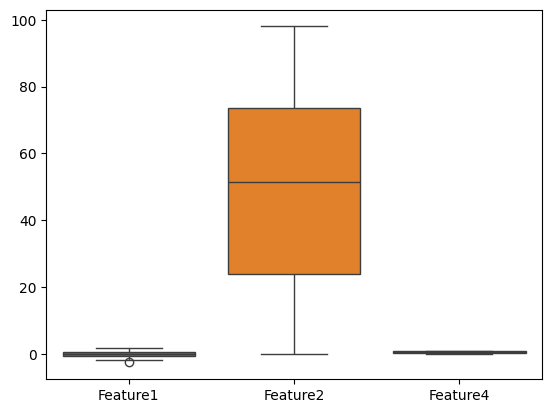

In [28]:
sns.boxplot(sample_df)

In [29]:
X = sample_df.drop(columns='Target')
y= sample_df.Target

In [30]:
X

,Feature1,Feature2,Feature3,Feature4
0,0.496714,8.0,C,0.293592
1,-0.138264,61.0,B,0.809361
2,0.647689,36.0,A,0.810113
3,1.523030,96.0,C,NaN
4,NaN,50.0,NaN,0.913241
...,...,...,...,...
95,-1.463515,31.0,A,0.941465
96,0.296120,8.0,A,0.386103
97,0.261055,98.0,C,0.961191
98,0.005113,18.0,B,0.905351


In [31]:
#Example
# impute = SimpleImputer(strategy='mean')
# impute.fit_transform(X)

In [33]:
xtrain

,Age,Salary,Credit_Score,Loan_Amount,Loan_Term,Employment_Status,Residence_Type,Previous_Default
29,44,85441,507,17109,24 months,Self-Employed,Rented,No
535,38,87298,489,10776,36 months,Employed,Mortgage,No
695,45,49629,762,39441,36 months,Employed,Mortgage,No
557,47,75337,809,40596,12 months,Employed,Mortgage,Yes
836,46,101121,504,31956,36 months,Unemployed,Mortgage,No
...,...,...,...,...,...,...,...,...
106,52,118723,689,31649,36 months,Employed,Rented,No
270,26,135654,388,22514,48 months,Self-Employed,Mortgage,Yes
860,64,135005,683,8642,36 months,Unemployed,Rented,No
435,26,47856,841,45697,36 months,Unemployed,Mortgage,No


In [32]:
obj_pre = Pipeline(
    steps=[
        ('impute_mode',SimpleImputer(strategy='most_frequent')),
        ('encoder',OneHotEncoder())
    ]
)
pre = ColumnTransformer(
    transformers=[
        ('impute_mean',SimpleImputer(strategy='mean'),['Feature1','Feature2']),
        ('obj_pre',obj_pre,['Feature3'])
    ]
)
pipe = Pipeline(
    steps=[
        ('pre',pre),
        ('model',LogisticRegression())
    ]
)
pipe.fit(xtrain,ytrain)

ValueError: A given column is not a column of the dataframe

In [34]:
main_pipeline

,steps,"[('pre', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaling', ...), ('encoder', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [ ]:
# import pickle
# with open('model.pkl','wb+') as file:
#     pickle.dump(main_pipeline,file)
# pickle.dump()
# pickle.dumps()
#pickle.dumps(main_pipeline)

In [ ]:
# import pickle
# pickle.dumps(main_pipeline)

b'\x80\x04\x95F\x0b\x00\x00\x00\x00\x00\x00\x8c\x10sklearn.pipeline\x94\x8c\x08Pipeline\x94\x93\x94)\x81\x94}\x94(\x8c\x05steps\x94]\x94(\x8c\x03pre\x94\x8c#sklearn.compose._column_transformer\x94\x8c\x11ColumnTransformer\x94\x93\x94)\x81\x94}\x94(\x8c\x0ctransformers\x94]\x94(\x8c\x07scaling\x94\x8c\x1bsklearn.preprocessing._data\x94\x8c\x0eStandardScaler\x94\x93\x94)\x81\x94}\x94(\x8c\twith_mean\x94\x88\x8c\x08with_std\x94\x88\x8c\x04copy\x94\x88\x8c\x10_sklearn_version\x94\x8c\x051.7.0\x94ub\x8c\x18pandas.core.indexes.base\x94\x8c\n_new_Index\x94\x93\x94h\x1a\x8c\x05Index\x94\x93\x94}\x94(\x8c\x04data\x94\x8c\x16numpy._core.multiarray\x94\x8c\x0c_reconstruct\x94\x93\x94\x8c\x05numpy\x94\x8c\x07ndarray\x94\x93\x94K\x00\x85\x94C\x01b\x94\x87\x94R\x94(K\x01K\x04\x85\x94h$\x8c\x05dtype\x94\x93\x94\x8c\x02O8\x94\x89\x88\x87\x94R\x94(K\x03\x8c\x01|\x94NNNJ\xff\xff\xff\xffJ\xff\xff\xff\xffK?t\x94b\x89]\x94(\x8c\x03Age\x94\x8c\x06Salary\x94\x8c\x0cCredit_Score\x94\x8c\x0bLoan_Amount\x94et\x

In [39]:
import joblib

joblib.dump(main_pipeline,'model1.pkl')

['model1.pkl']

In [40]:
model_pipe = joblib.load('model.pkl')

In [41]:
model_pipe

,steps,"[('pre', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaling', ...), ('encoder', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
